# FOLIO + ProofWriter-NL Dataset for Dual-Signal SBFL Evaluation

This notebook demonstrates the **FOLIO + ProofWriter-NL** dataset artifact used for evaluating Dual-Signal Spectrum-Based Fault Localization (SBFL) in natural language reasoning.

The dataset combines two sources:
- **FOLIO** — first-order logic inference with NL premises, conclusions, and gold FOL annotations (1,204 examples, True/False/Unknown labels)
- **ProofWriter-NL RuleTaker depth-3** — 3-hop deduction chains in natural language (300 balanced examples, True/False labels)

All examples follow the `exp_sel_data_out` schema: `input` (premises + conclusion), `output` (gold label), and rich metadata fields.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
from loguru import logger
import matplotlib.pyplot as plt
from collections import Counter

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

The mini demo subset (6 examples: 3 FOLIO + 3 ProofWriter-NL) is loaded from GitHub with a local fallback for offline use.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-d8d250-dual-signal-spectrum-based-fault-localiz/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded dataset: {data['metadata']['total_examples']} total examples in full dataset")
logger.info(f"Datasets in mini demo: {[d['dataset'] for d in data['datasets']]}")

08:25:13|INFO   |Loaded dataset: 1504 total examples in full dataset


08:25:13|INFO   |Datasets in mini demo: ['folio', 'proofwriter_ruletaker_depth3']


## Label Maps and Constants

The original script defines two label maps to normalize labels from each dataset into a common set: `True`, `False`, `Unknown`.

In [5]:
FOLIO_LABEL_MAP = {"True": "True", "False": "False", "Uncertain": "Unknown"}
RULETAKER_LABEL_MAP = {"entailment": "True", "not entailment": "False"}

## FOLIO Dataset

FOLIO (First-Order Logic Inference) provides NL premises and conclusions with gold FOL annotations. Each example has:
- **input**: concatenated premises + conclusion as natural language
- **output**: `True`, `False`, or `Unknown` label
- **metadata**: gold FOL premises/conclusion, story_id, example_id, calibration flag

The script normalizes split names: the first 20 validation examples are marked as `calibration`.

In [6]:
# Load FOLIO examples from the demo data
folio_dataset = next(d for d in data["datasets"] if d["dataset"] == "folio")
folio_examples = folio_dataset["examples"]

logger.info(f"FOLIO examples in demo: {len(folio_examples)}")
for ex in folio_examples:
    logger.info(f"  label={ex['output']:8s}  conclusion={ex['metadata_conclusion'][:60]!r}")

08:25:14|INFO   |FOLIO examples in demo: 3


08:25:14|INFO   |  label=Unknown   conclusion='Well Done 3 is worth listening to.'


08:25:14|INFO   |  label=Unknown   conclusion='Mike is an old person living in a stable home.'


08:25:14|INFO   |  label=True      conclusion='Jack is solid at shooting 2-pointers or bad at mid-range sho'


## ProofWriter-NL RuleTaker depth-3

ProofWriter-NL uses natural language surface forms requiring **3-hop deduction chains**. Unlike FOLIO, it has no FOL annotations — `gold_fol_premises` is always `[]`. Labels are binary: `True` (entailment) or `False` (not entailment), balanced 50/50.

The script randomly samples 150 True + 150 False examples from the `depth-3ext-NatLang` config with `random.seed(42)` for reproducibility.

In [7]:
# Load ProofWriter examples from the demo data
pw_dataset = next(d for d in data["datasets"] if d["dataset"] == "proofwriter_ruletaker_depth3")
pw_examples = pw_dataset["examples"]

logger.info(f"ProofWriter examples in demo: {len(pw_examples)}")
for ex in pw_examples:
    logger.info(f"  label={ex['output']:8s}  conclusion={ex['metadata_conclusion'][:60]!r}")

08:25:14|INFO   |ProofWriter examples in demo: 3


08:25:14|INFO   |  label=True      conclusion='The cat does not chase the rabbit.'


08:25:14|INFO   |  label=True      conclusion='Dave is not white.'


08:25:14|INFO   |  label=True      conclusion='Charlie is quiet.'


## Output Schema

All examples are merged into a unified `exp_sel_data_out` schema. The full dataset contains 1,504 examples across 2 datasets.

In [8]:
output = {
    "metadata": {
        "description": "FOLIO + ProofWriter-NL dataset for Dual-Signal SBFL evaluation",
        "folio_source": "HannaAbiAkl/FOLIO-KR (mirrors yale-nlp/FOLIO with additional KR notations)",
        "proofwriter_source": "tasksource/ruletaker config=depth-3ext-NatLang",
        "total_examples": data["metadata"]["total_examples"],
    },
    "datasets": [
        {
            "dataset": "folio",
            "examples": folio_examples,
        },
        {
            "dataset": "proofwriter_ruletaker_depth3",
            "examples": pw_examples,
        },
    ],
}

all_examples = folio_examples + pw_examples
logger.info(f"Total examples in demo subset: {len(all_examples)}")
logger.info(f"Schema keys: {list(all_examples[0].keys())}")

08:25:14|INFO   |Total examples in demo subset: 6


08:25:14|INFO   |Schema keys: ['input', 'output', 'metadata_fold', 'metadata_split', 'metadata_is_calibration_doc', 'metadata_gold_label', 'metadata_premises_text', 'metadata_conclusion', 'metadata_gold_fol_premises', 'metadata_gold_fol_conclusion', 'metadata_story_id', 'metadata_example_id', 'metadata_task_type', 'metadata_fold_name']


## Results Visualization

Summary of label distributions and dataset statistics for the demo subset.

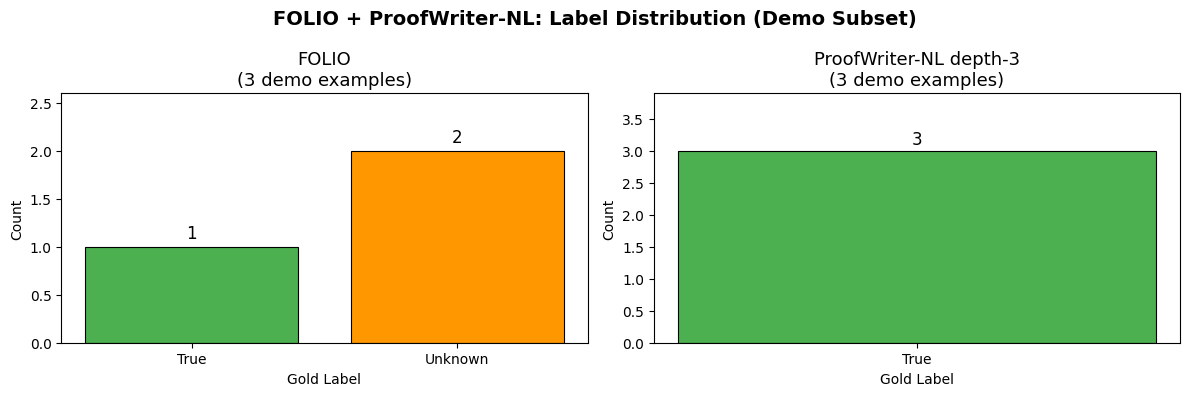


--- Sample FOLIO Example ---
Input (truncated): Premises: Tyga is a rapper. Rappers release rap albums. Tyga released the Well Done 3 album. Rappers are not opera singers.
Conclusion: Well Done 3 is worth listening to....
Output: Unknown
FOL Conclusion: IsWorthListening(wellDone3)

--- Sample ProofWriter-NL Example ---
Input (truncated): Premises: The bear chases the rabbit. The bear is blue. The bear is green. The cat is cold. The rabbit chases the cat. The rabbit is nice. The rabbit visits the bear. If someone chases the cat and the...
Output: True
Fold: proofwriter


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution per dataset
for ax, (ds_name, examples) in zip(axes, [("FOLIO", folio_examples), ("ProofWriter-NL depth-3", pw_examples)]):
    label_counts = Counter(ex["output"] for ex in examples)
    labels = sorted(label_counts)
    counts = [label_counts[l] for l in labels]
    colors = {"True": "#4CAF50", "False": "#F44336", "Unknown": "#FF9800"}
    bar_colors = [colors.get(l, "#9E9E9E") for l in labels]
    ax.bar(labels, counts, color=bar_colors, edgecolor="black", linewidth=0.8)
    ax.set_title(f"{ds_name}\n({len(examples)} demo examples)", fontsize=13)
    ax.set_xlabel("Gold Label")
    ax.set_ylabel("Count")
    for i, (l, c) in enumerate(zip(labels, counts)):
        ax.text(i, c + 0.05, str(c), ha="center", va="bottom", fontsize=12)
    ax.set_ylim(0, max(counts) * 1.3)

plt.suptitle("FOLIO + ProofWriter-NL: Label Distribution (Demo Subset)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print a sample example from each dataset
print("\n--- Sample FOLIO Example ---")
ex = folio_examples[0]
print(f"Input (truncated): {ex['input'][:200]}...")
print(f"Output: {ex['output']}")
print(f"FOL Conclusion: {ex['metadata_gold_fol_conclusion']}")

print("\n--- Sample ProofWriter-NL Example ---")
ex = pw_examples[0]
print(f"Input (truncated): {ex['input'][:200]}...")
print(f"Output: {ex['output']}")
print(f"Fold: {ex['metadata_fold_name']}")